In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
df = pd.read_csv("cleaned_india_city_climate.csv")

In [7]:
df.columns = df.columns.str.strip().str.lower()
print("Available columns:", df.columns.tolist())

Available columns: ['date', 'year', 'month_num', 'month', 'season', 'city', 'tavg', 'tmin', 'tmax', 'prcp', 'pres']


In [8]:
num_col = "temperature" if "temperature" in df.columns else df.select_dtypes(include="number").columns[0]
cat_col = "city" if "city" in df.columns else df.select_dtypes(include="object").columns[0]


top_cats = df[cat_col].value_counts().head(5).index
filtered_df = df[df[cat_col].isin(top_cats)]

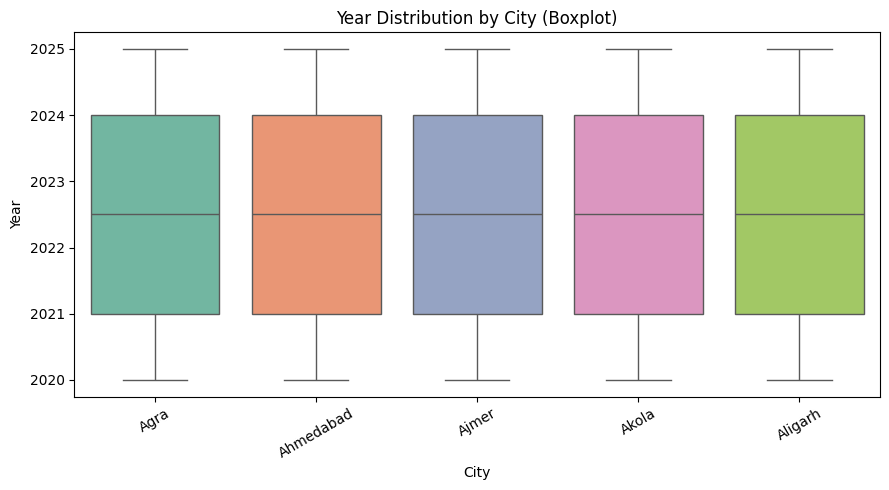

In [9]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=filtered_df, x=cat_col, y=num_col, hue=cat_col, palette="Set2")
plt.title(f"{num_col.title()} Distribution by {cat_col.title()} (Boxplot)")
plt.xlabel(cat_col.title())
plt.ylabel(num_col.title())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

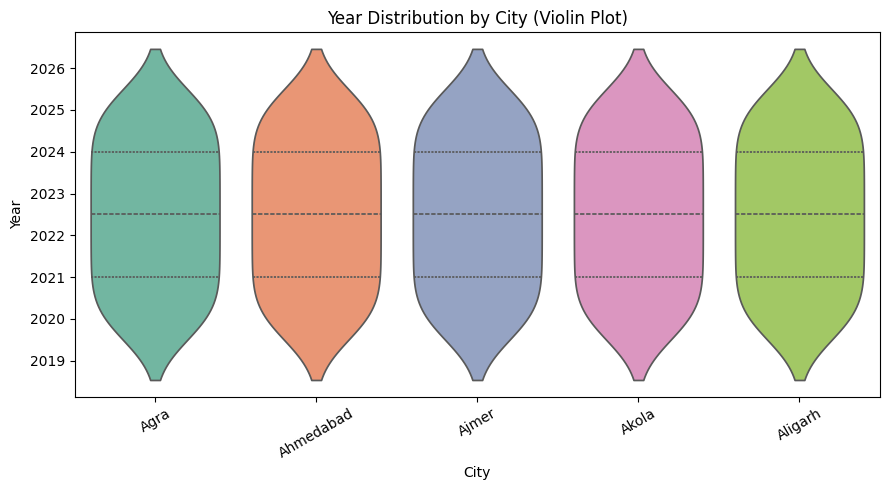

In [10]:
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=filtered_df,
    x=cat_col,
    y=num_col,
    hue=cat_col,
    palette="Set2",
    inner="quartile",
)
plt.title(f"{num_col.title()} Distribution by {cat_col.title()} (Violin Plot)")
plt.xlabel(cat_col.title())
plt.ylabel(num_col.title())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

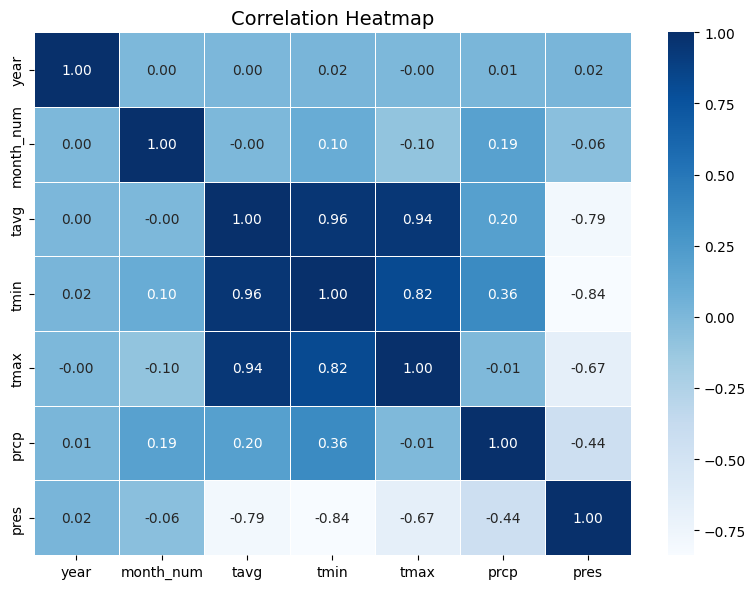

In [14]:
numeric_df = df.select_dtypes(include=["number"])


corr_matrix = numeric_df.corr()


plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
)


plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/usr/local/lib/python3.13/dist-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


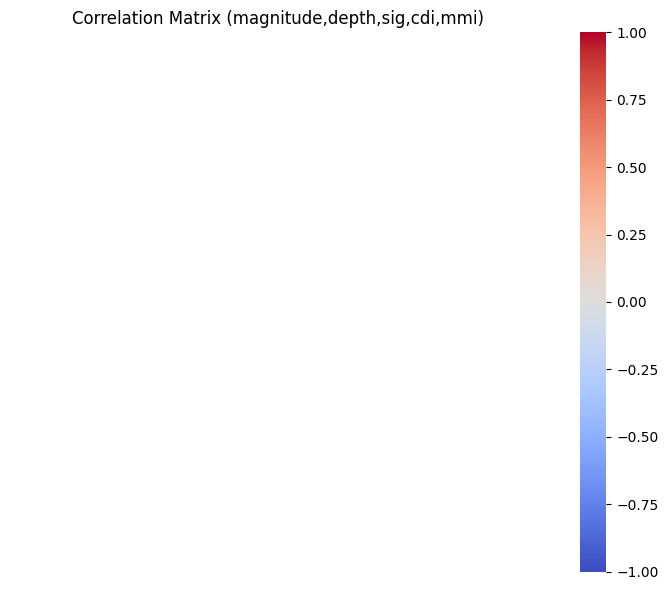

In [16]:
cols = ["magnitude", "depth", "sig", "cdi", "mmi"]
valid_cols = [c for c in cols if c in df.columns]

corr_matrix = df[valid_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
)

plt.title("Correlation Matrix (magnitude,depth,sig,cdi,mmi)")
plt.tight_layout()
plt.show()

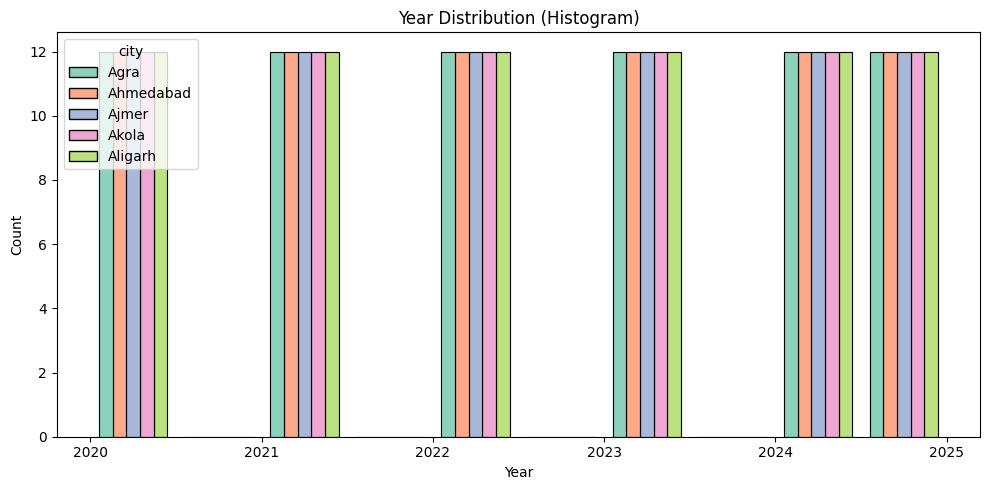

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=filtered_df,
    x=num_col,
    hue=cat_col,
    palette="Set2",
    bins=10,
    kde=False,
    multiple="dodge",
    shrink=0.8,
)

plt.title(f"{num_col.title()} Distribution (Histogram)")
plt.xlabel(num_col.title())
plt.ylabel("Count")
plt.tight_layout()
plt.show()